In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='husl')

rfm = pd.read_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\rfm_features.csv'
)


rfm.head()

,Customer ID,recency,frequency,monetary,avg_order_value,is_high_value,churned,rolling_7d,rolling_30d,total_days,unique_months,unique_products,avg_basket_size,purchase_rate,days_as_customer
0,12346,160,11,372.86,33.90,0,0,53.27,53.27,196,4,26,2.12,0.06,357
1,12347,35,1,611.53,611.53,0,0,611.53,611.53,0,1,40,12.72,1.00,35
2,12348,69,1,222.16,222.16,0,0,222.16,222.16,0,1,20,18.65,1.00,69
3,12349,39,3,2671.14,890.38,1,0,890.38,890.38,181,3,90,9.74,0.02,220
4,12351,6,1,300.93,300.93,0,1,300.93,300.93,0,1,21,12.43,1.00,6


In [2]:
cluster_features = ['recency', 'frequency', 'monetary']

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[cluster_features])

print("=== Before scaling ===")
print(rfm[cluster_features].describe().round(2))
print("\n=== After scaling ===")
scaled_df = pd.DataFrame(rfm_scaled, columns=cluster_features)
print(scaled_df.describe().round(2))

=== Before scaling ===
       recency  frequency  monetary
count  4291.00    4291.00   4291.00
mean     89.67       4.37   2040.77
std      95.63       8.00   8722.97
min       1.00       1.00      2.95
25%      18.00       1.00    309.12
50%      51.00       2.00    712.62
75%     133.00       5.00   1703.02
max     370.00     201.00 321329.74

=== After scaling ===
       recency  frequency  monetary
count  4291.00    4291.00   4291.00
mean      0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -0.93      -0.42     -0.23
25%      -0.75      -0.42     -0.20
50%      -0.40      -0.30     -0.15
75%       0.45       0.08     -0.04
max       2.93      24.60     36.61


K=2 → inertia: 8605 silhouette: 0.924
K=3 → inertia: 5083 silhouette: 0.590
K=4 → inertia: 3507 silhouette: 0.609
K=5 → inertia: 2706 silhouette: 0.575
K=6 → inertia: 2218 silhouette: 0.524
K=7 → inertia: 1796 silhouette: 0.503
K=8 → inertia: 1545 silhouette: 0.503
K=9 → inertia: 1364 silhouette: 0.441
K=10 → inertia: 1220 silhouette: 0.410


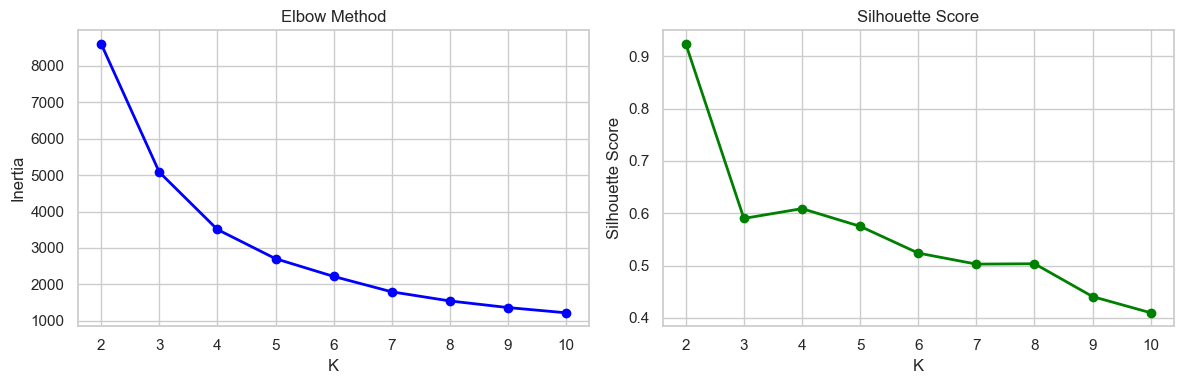

In [3]:
silhouettes = []
inertias=[]
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))
    print(f"K={k} → inertia: {km.inertia_:.0f} silhouette: {silhouettes[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes, 'go-', linewidth=2)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('../reports/05_elbow_curve.png', dpi=150)
plt.show()

In [4]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

rfm['cluster'] = kmeans.labels_

cluster_summary = rfm.groupby('cluster').agg(
    count     = ('Customer ID', 'count'),
    recency   = ('recency', 'mean'),
    frequency = ('frequency', 'mean'),
    monetary  = ('monetary', 'mean')
).round(2)
print(cluster_summary)
print(f"\nSilhouette score: {silhouette_score(rfm_scaled, kmeans.labels_):.3f}")

         count  recency  frequency  monetary
cluster                                     
0           26     9.38      64.69  40454.04
1          367    18.61      15.05   7153.18
2            5     6.80     112.00 210240.71
3         2875    45.70       3.24   1192.36
4         1018   241.94       1.64    590.06

Silhouette score: 0.575


=== Segment Distribution ===
segment
New Customers    2875
At Risk          1018
Loyal             367
Champions          26
VIP                 5
Name: count, dtype: int64


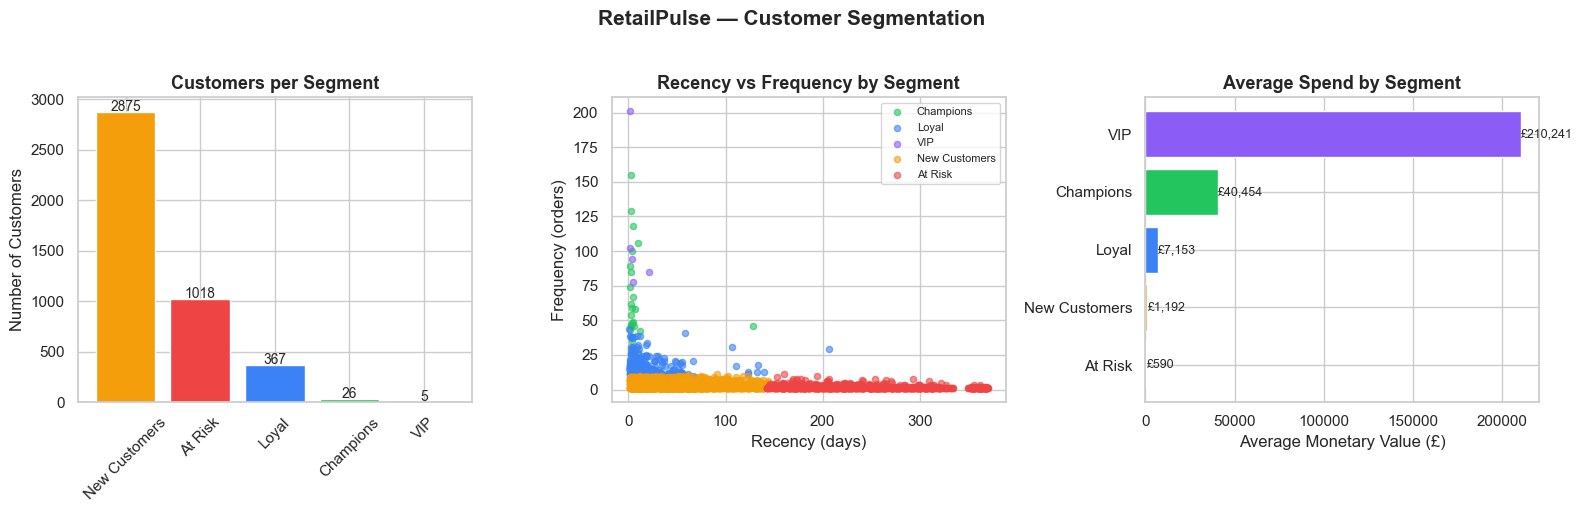

✓ Chart saved to reports/06_segments.png


In [7]:
segment_map = {
    0: 'Champions',
    1: 'Loyal',
    2: 'VIP',
    3: 'New Customers',
    4: 'At Risk'
}
rfm['segment'] = rfm['cluster'].map(segment_map)

print("=== Segment Distribution ===")
print(rfm['segment'].value_counts())

colors = {
    'Champions':    '#22C55E',
    'Loyal':        '#3B82F6',
    'VIP':          '#8B5CF6',
    'New Customers':'#F59E0B',
    'At Risk':      '#EF4444'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# chart 1 — segment sizes
seg_counts = rfm['segment'].value_counts()
axes[0].bar(
    seg_counts.index,
    seg_counts.values,
    color=[colors[s] for s in seg_counts.index]
)
axes[0].set_title('Customers per Segment',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 10, str(v),
                 ha='center', fontsize=10)

# chart 2 — recency vs frequency scatter
for seg, color in colors.items():
    mask = rfm['segment'] == seg
    axes[1].scatter(
        rfm[mask]['recency'],
        rfm[mask]['frequency'],
        c=color, label=seg,
        alpha=0.6, s=20
    )
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Frequency (orders)')
axes[1].set_title('Recency vs Frequency by Segment',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8)

# chart 3 — average monetary by segment
seg_monetary = rfm.groupby('segment')['monetary']\
                  .mean().sort_values(ascending=True)
axes[2].barh(
    seg_monetary.index,
    seg_monetary.values,
    color=[colors[s] for s in seg_monetary.index]
)
axes[2].set_title('Average Spend by Segment',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Average Monetary Value (£)')
for i, v in enumerate(seg_monetary.values):
    axes[2].text(v + 100, i, f'£{v:,.0f}',
                 va='center', fontsize=9)

plt.suptitle('RetailPulse — Customer Segmentation',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/06_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved to reports/06_segments.png")

In [8]:
segment_report = rfm.groupby('segment').agg(
    customer_count = ('Customer ID', 'count'),
    avg_recency    = ('recency', 'mean'),
    avg_frequency  = ('frequency', 'mean'),
    avg_monetary   = ('monetary', 'mean'),
    total_revenue  = ('monetary', 'sum'),
    churn_rate     = ('churned', 'mean')
).round(2).reset_index()

segment_report['revenue_share'] = (
    segment_report['total_revenue'] /
    segment_report['total_revenue'].sum() * 100
).round(1)

segment_report = segment_report.sort_values(
    'total_revenue', ascending=False
).reset_index(drop=True)

print("=== Segment Business Report ===")
print(segment_report.to_string(index=False))

print(f"\n=== Key Business Insights ===")
for _, row in segment_report.iterrows():
    print(f"\n{row['segment']}:")
    print(f"  Customers:     {row['customer_count']:,}")
    print(f"  Avg recency:   {row['avg_recency']:.0f} days")
    print(f"  Avg frequency: {row['avg_frequency']:.1f} orders")
    print(f"  Avg spend:     £{row['avg_monetary']:,.0f}")
    print(f"  Revenue share: {row['revenue_share']:.1f}%")
    print(f"  Churn rate:    {row['churn_rate']:.1%}")

# save files
import os
os.makedirs(
    r'C:\Users\Ashut\Retailpulse\data\processed',
    exist_ok=True
)
os.makedirs(
    r'C:\Users\Ashut\Retailpulse\reports',
    exist_ok=True
)

rfm.to_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\rfm_segments.csv',
    index=False
)
segment_report.to_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\segment_report.csv',
    index=False
)

print(f"\n✓ Saved rfm_segments.csv — {rfm.shape[0]:,} customers")
print(f"✓ Saved segment_report.csv — {segment_report.shape[0]} segments")

# verify segment column exists
print(f"\n=== Verification ===")
print(f"Segments in rfm_segments.csv:")
print(rfm['segment'].value_counts().to_string())

print(f"\nColumns in rfm_segments.csv:")
print(rfm.columns.tolist())

print(f"""
==================================================
DAY 3 COMPLETE — SUMMARY
==================================================
Total customers segmented: {rfm.shape[0]:,}
Segments created: {rfm['segment'].nunique()}
Silhouette score: 0.575 (strong clustering)

Segment breakdown:
""")
for _, row in segment_report.iterrows():
    pct = row['customer_count']/rfm.shape[0]*100
    print(f"  {row['segment']:15s} → "
          f"{row['customer_count']:4,} customers "
          f"({pct:.1f}%) | "
          f"Revenue share: {row['revenue_share']:.1f}%")

=== Segment Business Report ===
      segment  customer_count  avg_recency  avg_frequency  avg_monetary  total_revenue  churn_rate  revenue_share
New Customers            2875        45.70           3.24       1192.36     3428028.55        0.32          39.10
        Loyal             367        18.61          15.05       7153.18     2625218.48        0.04          30.00
    Champions              26         9.38          64.69      40454.04     1051805.01        0.12          12.00
          VIP               5         6.80         112.00     210240.71     1051203.54        0.00          12.00
      At Risk            1018       241.94           1.64        590.06      600684.44        0.64           6.90

=== Key Business Insights ===

New Customers:
  Customers:     2,875
  Avg recency:   46 days
  Avg frequency: 3.2 orders
  Avg spend:     £1,192
  Revenue share: 39.1%
  Churn rate:    32.0%

Loyal:
  Customers:     367
  Avg recency:   19 days
  Avg frequency: 15.1 orders
  Avg sp